#Xavier Initialization + SGD vs Adam

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
import matplotlib.pyplot as plt

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.5469 - loss: 1.6577 - val_accuracy: 0.8877 - val_loss: 0.5167
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8662 - loss: 0.5300 - val_accuracy: 0.9128 - val_loss: 0.3433
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8908 - loss: 0.3985 - val_accuracy: 0.9203 - val_loss: 0.2907
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9028 - loss: 0.3472 - val_accuracy: 0.9268 - val_loss: 0.2629
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9101 - loss: 0.3163 - val_accuracy: 0.9308 - val_loss: 0.2441
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9159 - loss: 0.2941 - val_accuracy: 0.9353 - val_loss: 0.2296
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9208 - loss: 0.2766 - val_accuracy: 0.9392 - val_loss: 0.2176
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9249 - loss: 0.2619 - val_acc

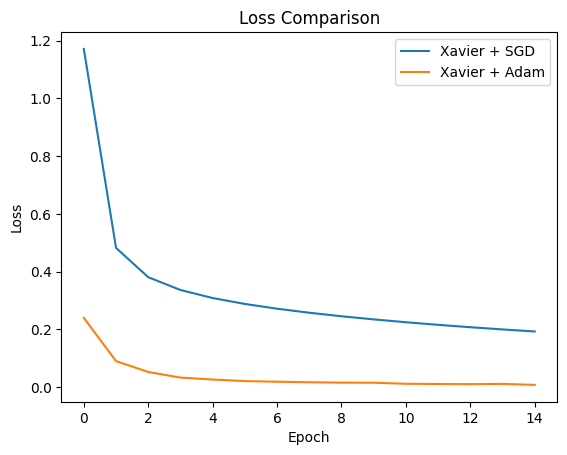

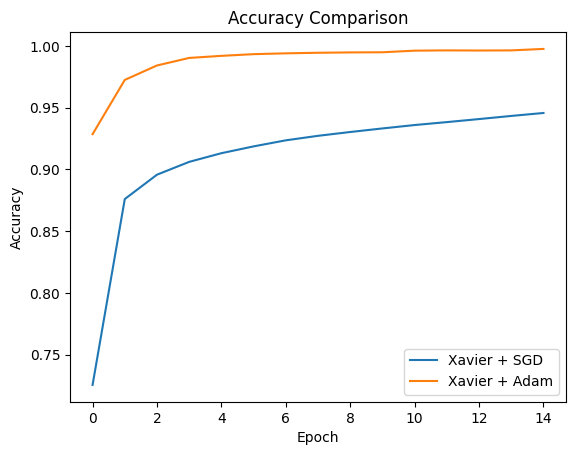

Test Accuracy (SGD): 0.945900022983551
Test Accuracy (Adam): 0.980400025844574


In [ ]:
# Set random seeds so results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

# Load MNIST handwritten digit dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values from 0–255 to 0–1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28x28 images into 784-length vectors for MLP input
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert class labels to one-hot encoded vectors
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Function to build MLP model with Xavier (Glorot) initialization
def build_model():
    init = initializers.GlorotUniform()  # Xavier initializer

    model = keras.Sequential([
        layers.Dense(512, activation="relu",
                     kernel_initializer=init,
                     input_shape=(784,)),
        layers.Dense(256, activation="relu",
                     kernel_initializer=init),
        layers.Dense(10, activation="softmax")
    ])
    return model

# Build and compile model using SGD optimizer
model_sgd = build_model()
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model with SGD
hist_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

# Build and compile model using Adam optimizer
model_adam = build_model()
model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model with Adam
hist_adam = model_adam.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

# Plot training loss comparison
plt.plot(hist_sgd.history["loss"], label="Xavier + SGD")
plt.plot(hist_adam.history["loss"], label="Xavier + Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.show()

# Plot training accuracy comparison
plt.plot(hist_sgd.history["accuracy"], label="Xavier + SGD")
plt.plot(hist_adam.history["accuracy"], label="Xavier + Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

# Evaluate both models on test data
sgd_loss, sgd_acc = model_sgd.evaluate(x_test, y_test, verbose=0)
adam_loss, adam_acc = model_adam.evaluate(x_test, y_test, verbose=0)

print("Test Accuracy (SGD):", sgd_acc)
print("Test Accuracy (Adam):", adam_acc)


#He Initialization + SGD vs Adam

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers
import matplotlib.pyplot as plt

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5922 - loss: 1.5189 - val_accuracy: 0.8930 - val_loss: 0.4630
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8731 - loss: 0.4882 - val_accuracy: 0.9150 - val_loss: 0.3207
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8961 - loss: 0.3754 - val_accuracy: 0.9255 - val_loss: 0.2725
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9083 - loss: 0.3270 - val_accuracy: 0.9327 - val_loss: 0.2454
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9159 - loss: 0.2967 - val_accuracy: 0.9377 - val_loss: 0.2268
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9213 - loss: 0.2745 - val_accuracy: 0.9425 - val_loss: 0.2125
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9261 - loss: 0.2569 - val_accuracy: 0.9455 - val_loss: 0.2008
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9297 - loss: 0.2422 - val_ac

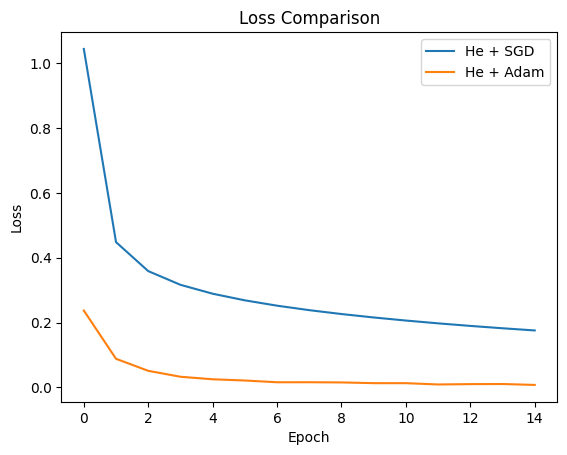

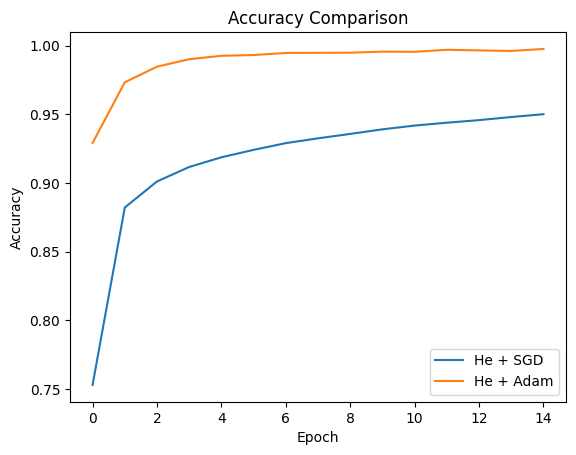

Test Accuracy (He + SGD): 0.9496999979019165
Test Accuracy (He + Adam): 0.9819999933242798


In [ ]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values to range 0–1
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten 28x28 images into 784-length vectors
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# Convert labels to one-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# Function to build MLP model with He initialization
def build_model():
    init = initializers.HeNormal()  # He initializer (best for ReLU)

    model = keras.Sequential([
        layers.Dense(512, activation="relu",
                     kernel_initializer=init,
                     input_shape=(784,)),
        layers.Dense(256, activation="relu",
                     kernel_initializer=init),
        layers.Dense(10, activation="softmax")
    ])
    return model

# Build and compile model using SGD optimizer
model_sgd = build_model()
model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model with SGD
hist_sgd = model_sgd.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

# Build and compile model using Adam optimizer
model_adam = build_model()
model_adam.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model with Adam
hist_adam = model_adam.fit(
    x_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.1
)

# Plot training loss comparison
plt.plot(hist_sgd.history["loss"], label="He + SGD")
plt.plot(hist_adam.history["loss"], label="He + Adam")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.show()

# Plot training accuracy comparison
plt.plot(hist_sgd.history["accuracy"], label="He + SGD")
plt.plot(hist_adam.history["accuracy"], label="He + Adam")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

# Evaluate both models on test data
sgd_loss, sgd_acc = model_sgd.evaluate(x_test, y_test, verbose=0)
adam_loss, adam_acc = model_adam.evaluate(x_test, y_test, verbose=0)

print("Test Accuracy (He + SGD):", sgd_acc)
print("Test Accuracy (He + Adam):", adam_acc)
